# QBL Prime-Pattern Watch

This notebook studies the domain-indexed counts generated by the clean primitive custody law only.

\[
N_A=6\cdot 2^A,\qquad Q_A=N_A-1=6\cdot2^A-1=3\cdot2^{A+1}-1.
\]

For the current terminal floor-crossing convention,

\[
\Delta_A=2^{12(2^{A+1}-1)},\qquad
T_A=\min\{m:F_{m+1}F_{m+2}\ge \Delta_A\},\qquad
B_A=T_A-T_{A-1}.
\]

No R/S/T scheduler is used. Every code cell prints a PASS/FAIL statement and emits one figure.

PASS
Q-prime domains through A=100: [0, 1, 2, 3, 5, 6, 10, 17, 33, 37, 42, 54, 63, 75, 93]


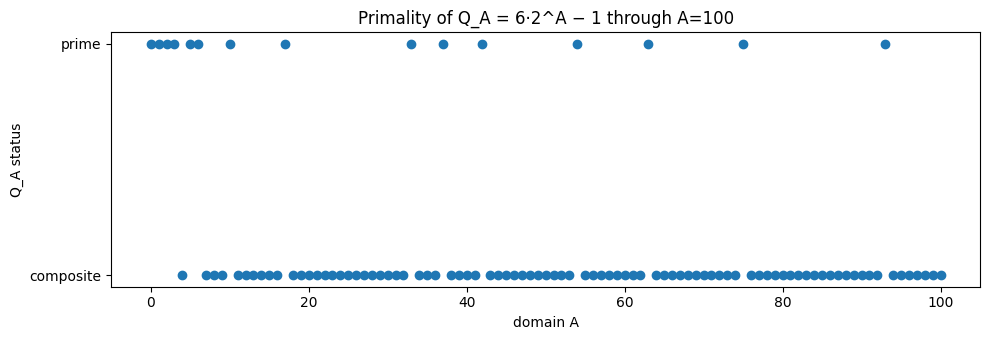

In [1]:
import math
import mpmath as mp
import sympy as sp
import matplotlib.pyplot as plt

mp.mp.dps = 400

def q_count(A):
    return 6 * (1 << A) - 1

def n_final(A):
    return 6 * ((1 << (A + 1)) - 1)

def t_count(A):
    if A < 0:
        return 0
    phi = (1 + mp.sqrt(5)) / 2
    log_delta = 2 * n_final(A) * mp.log(2)
    root = (log_delta + mp.log(5)) / (2 * mp.log(phi)) - mp.mpf('1.5')
    return int(mp.ceil(root))

def b_count(A):
    return t_count(A) - t_count(A - 1)

A = list(range(101))
Q = [q_count(a) for a in A]
Q_prime = [bool(sp.isprime(q)) for q in Q]
expected_prefix = [5, 11, 23, 47, 95, 191, 383, 767]
passed = Q[:8] == expected_prefix and all(q_count(a) == 3 * (1 << (a + 1)) - 1 for a in A)
print('PASS' if passed else 'FAIL')
print('Q-prime domains through A=100:', [a for a, flag in zip(A, Q_prime) if flag])

plt.figure(figsize=(10, 3.5))
plt.scatter(A, [1 if flag else 0 for flag in Q_prime])
plt.yticks([0, 1], ['composite', 'prime'])
plt.xlabel('domain A')
plt.ylabel('Q_A status')
plt.title('Primality of Q_A = 6·2^A − 1 through A=100')
plt.tight_layout()
plt.show()

## Claim 1: the Q sequence is a shifted Thabit sequence with periodic modular composite classes

p=5: A ≡ 0 (mod 4), residues=[0, 0, 0, 0, 0, 0, 0, 0]
p=11: A ≡ 1 (mod 10), residues=[0, 0, 0, 0, 0, 0, 0, 0]
p=23: A ≡ 2 (mod 11), residues=[0, 0, 0, 0, 0, 0, 0, 0]
p=47: A ≡ 3 (mod 23), residues=[0, 0, 0, 0, 0, 0, 0, 0]
p=13: A ≡ 7 (mod 12), residues=[0, 0, 0, 0, 0, 0, 0, 0]
PASS


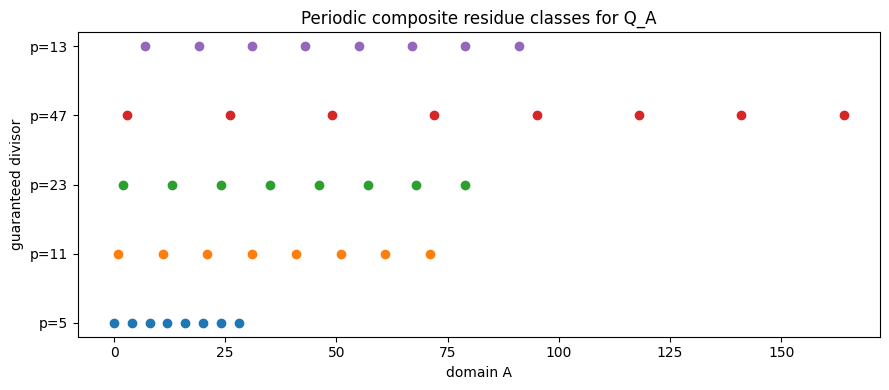

In [2]:
from sympy.ntheory import n_order

examples = [
    (5, 0, 4),
    (11, 1, 10),
    (23, 2, 11),
    (47, 3, 23),
    (13, 7, 12),
]
checks = []
for p, r, period in examples:
    values = [q_count(r + period * k) % p for k in range(8)]
    checks.append(all(v == 0 for v in values))
    print(f'p={p}: A ≡ {r} (mod {period}), residues={values}')

passed = all(checks)
print('PASS' if passed else 'FAIL')

plt.figure(figsize=(9, 4))
for row, (p, r, period) in enumerate(examples):
    xs = [r + period * k for k in range(8)]
    plt.scatter(xs, [row] * len(xs), label=f'{p} divides Q_A')
plt.yticks(range(len(examples)), [f'p={p}' for p, _, _ in examples])
plt.xlabel('domain A')
plt.ylabel('guaranteed divisor')
plt.title('Periodic composite residue classes for Q_A')
plt.tight_layout()
plt.show()

## Claim 2: B counts form an irrational near-doubling sequence under the current floor-crossing law

PASS
alpha = 8.64252054247533887410530899753
B-prime domains through A=100: [4, 17, 56, 72]
first 20 B counts: [9, 18, 34, 69, 139, 276, 553, 1107, 2212, 4425, 8850, 17700, 35400, 70799, 141599, 283198, 566396, 1132793, 2265585, 4531170]


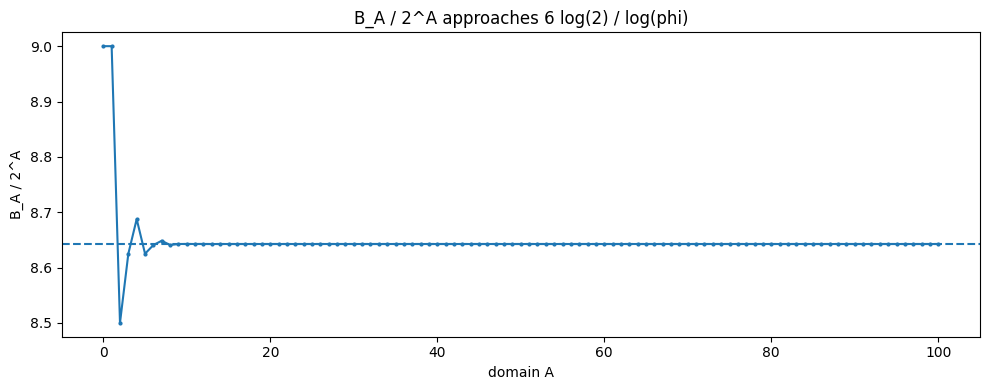

In [3]:
A = list(range(101))
T = [t_count(a) for a in A]
B = [T[a] - (T[a-1] if a else 0) for a in A]
alpha = 6 * mp.log(2) / mp.log((1 + mp.sqrt(5)) / 2)
expected_prefix = [9, 18, 34, 69, 139, 276, 553, 1107, 2212, 4425]
passed = B[:10] == expected_prefix
print('PASS' if passed else 'FAIL')
print('alpha =', mp.nstr(alpha, 30))
print('B-prime domains through A=100:', [a for a, b in zip(A, B) if sp.isprime(b)])
print('first 20 B counts:', B[:20])

plt.figure(figsize=(10, 4))
plt.plot(A, [mp.mpf(B[a]) / (1 << a) for a in A], marker='o', markersize=2)
plt.axhline(float(alpha), linestyle='--')
plt.xlabel('domain A')
plt.ylabel('B_A / 2^A')
plt.title('B_A / 2^A approaches 6 log(2) / log(phi)')
plt.tight_layout()
plt.show()

## Claim 3: Q-prime and B-prime domains are sparse and mostly unsynchronized

PASS
Q-prime domains through A=1000: [0, 1, 2, 3, 5, 6, 10, 17, 33, 37, 42, 54, 63, 75, 93, 102, 142, 205, 215, 305, 323, 390, 457, 469, 826]
B-prime domains through A=1000: [4, 17, 56, 72, 147, 177, 200, 294, 367, 878]
simultaneous-prime domains through A=1000: [17]
A=17 values: 786431 1132793


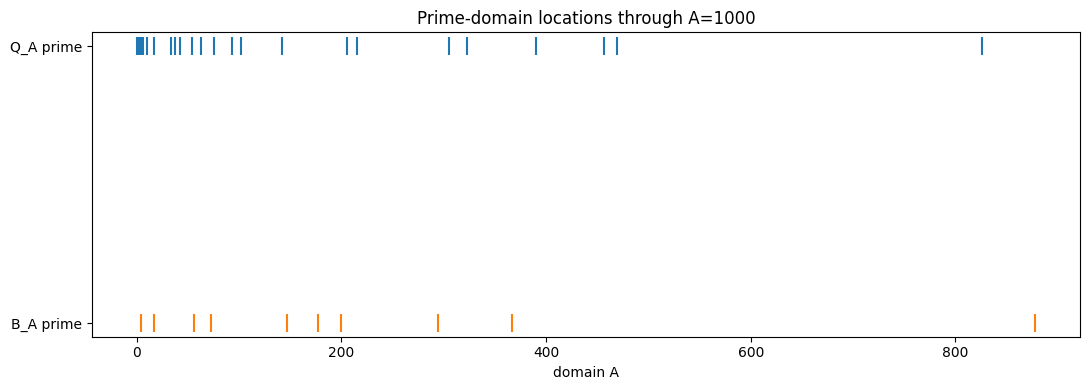

In [4]:
A = list(range(1001))
Q = [q_count(a) for a in A]
T = [t_count(a) for a in A]
B = [T[a] - (T[a-1] if a else 0) for a in A]
q_prime_A = [a for a, q in zip(A, Q) if sp.isprime(q)]
b_prime_A = [a for a, b in zip(A, B) if sp.isprime(b)]
both = sorted(set(q_prime_A) & set(b_prime_A))
passed = both == [17]
print('PASS' if passed else 'FAIL')
print('Q-prime domains through A=1000:', q_prime_A)
print('B-prime domains through A=1000:', b_prime_A)
print('simultaneous-prime domains through A=1000:', both)
print('A=17 values:', q_count(17), b_count(17))

plt.figure(figsize=(11, 4))
plt.scatter(q_prime_A, [1] * len(q_prime_A), marker='|', s=180, label='Q_A prime')
plt.scatter(b_prime_A, [0] * len(b_prime_A), marker='|', s=180, label='B_A prime')
plt.yticks([0, 1], ['B_A prime', 'Q_A prime'])
plt.xlabel('domain A')
plt.title('Prime-domain locations through A=1000')
plt.tight_layout()
plt.show()

## Claim 4: the B sequence has a bounded near-doubling correction

PASS
observed correction values: [-2, -1, 0, 1, 2]
frequencies: {-2: 121, -1: 251, 0: 244, 1: 275, 2: 109}
Every B_A prime for A>0 occurs at correction ±1 through A=1000: True


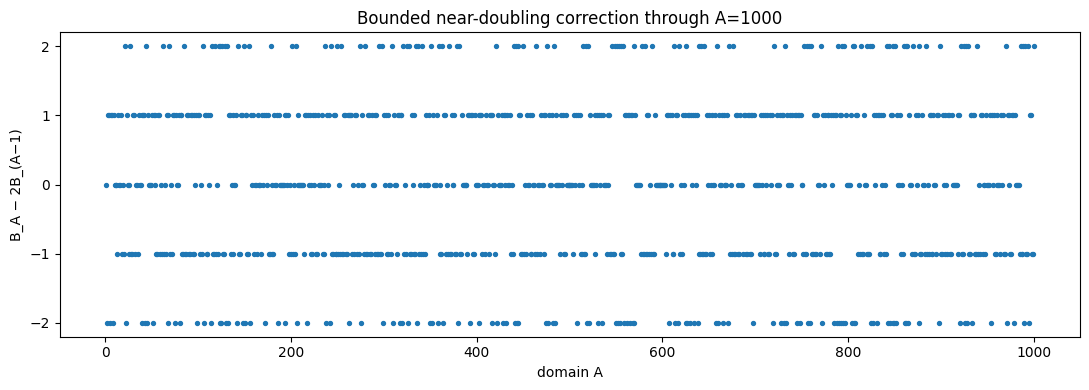

In [5]:
A = list(range(1001))
T = [t_count(a) for a in A]
B = [T[a] - (T[a-1] if a else 0) for a in A]
correction = [B[a] - 2 * B[a-1] for a in range(1, len(B))]
allowed = {-2, -1, 0, 1, 2}
prime_gate_pass = all((not sp.isprime(B[a])) or correction[a-1] in {-1, 1} for a in range(1, len(B)))
passed = set(correction).issubset(allowed) and prime_gate_pass
print('PASS' if passed else 'FAIL')
print('observed correction values:', sorted(set(correction)))
print('frequencies:', {d: correction.count(d) for d in sorted(set(correction))})
print('Every B_A prime for A>0 occurs at correction ±1 through A=1000:', prime_gate_pass)

plt.figure(figsize=(11, 4))
plt.scatter(range(1, len(B)), correction, s=8)
plt.yticks(sorted(allowed))
plt.xlabel('domain A')
plt.ylabel('B_A − 2B_(A−1)')
plt.title('Bounded near-doubling correction through A=1000')
plt.tight_layout()
plt.show()

## Interpretation boundary

- The formula for `Q_A` is exact and identifies a known Thabit-number subsequence.
- The modular divisor progressions are exact.
- The `B_A` sequence is conditional on the current terminal floor-crossing convention stated above.
- The finite scans do not prove that the displayed prime-domain lists are complete beyond their declared range.
- The coincidence at `A=17` is a real finite witness, not yet a coupling theorem.